In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
image = cv2.imread('/Users/230070/Downloads/paris.jpg', cv2.IMREAD_GRAYSCALE)

In [3]:
print(cv2.__version__)

4.11.0


Part 1: Histogram Equalization

Text(0.5, 1.0, 'Histogram (Original)')

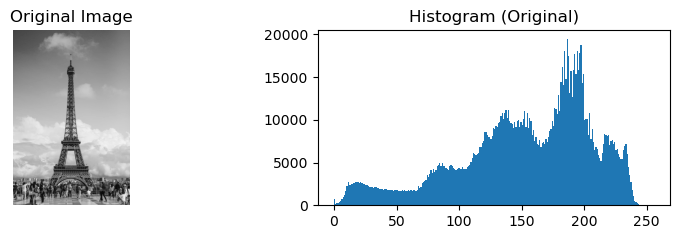

In [26]:
equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(10,5))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.hist(image.ravel(), 256, [0,256])
plt.title('Histogram (Original)')

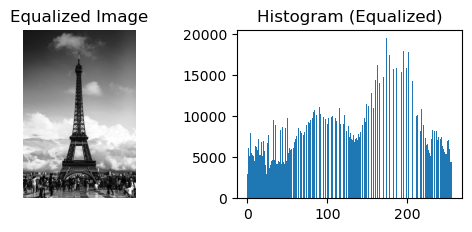

In [29]:
plt.subplot(2, 2, 3)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')


plt.subplot(2, 2, 4)
plt.hist(equalized_image.ravel(), 256, [0,256])
plt.title('Histogram (Equalized)')

plt.show()

Histogram equalization improves contrast by redistributing pixel intensity values over the full range (0–255). In poorly lit images, pixel values are concentrated in a small range. Equalization spreads them across the intensity spectrum, making details more visible and improving brightness balance.

Part 2: Histogram Equalization on Color Images

In [30]:
color_image = cv2.imread('/Users/230070/Downloads/paris.jpg')

In [33]:
(b, g, r) = cv2.split(color_image)

equalized_b = cv2.equalizeHist(b)
equalized_g = cv2.equalizeHist(g)
equalized_r = cv2.equalizeHist(r)

equalized_color_image = cv2.merge([equalized_b,
equalized_g, equalized_r])

(-0.5, 999.5, 1499.5, -0.5)

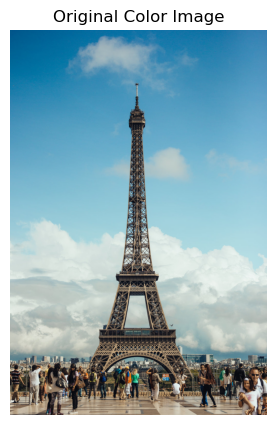

In [34]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_image,
cv2.COLOR_BGR2RGB))
plt.title('Original Color Image')
plt.axis('off')

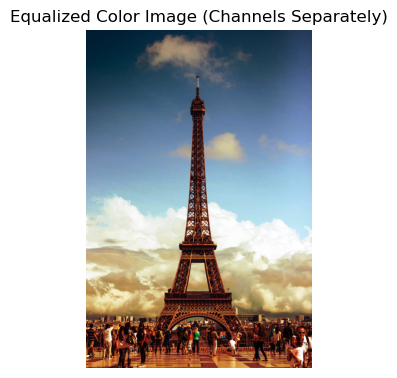

In [35]:
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(equalized_color_image,
cv2.COLOR_BGR2RGB))
plt.title('Equalized Color Image (Channels Separately)')
plt.axis('off')
plt.show()

When histogram equalization is applied separately to RGB channels, the contrast increases but color balance may change. This happens because each channel is stretched independently, which can alter the relationship between colors.

Part 3: Histogram Matching (Specification)

In [36]:
from skimage import exposure

In [37]:
image_source = cv2.imread('/Users/230070/Downloads/paris.jpg', cv2.IMREAD_GRAYSCALE)
image_target = cv2.imread('/Users/230070/Downloads/images.jpeg', cv2.IMREAD_GRAYSCALE)

Text(0.5, 1.0, 'Histogram (Source)')

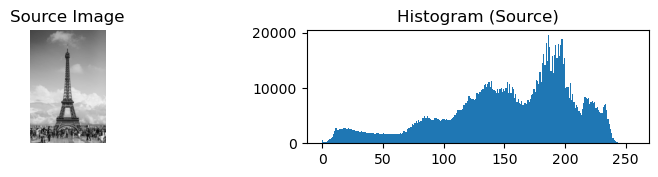

In [39]:
matched_image = exposure.match_histograms(image_source, image_target)

plt.figure(figsize=(15,5))

plt.subplot(3, 3, 1)
plt.imshow(image_source, cmap='gray')
plt.title('Source Image')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.hist(image_source.ravel(), 256, [0,256])
plt.title('Histogram (Source)')

Text(0.5, 1.0, 'Histogram (Target)')

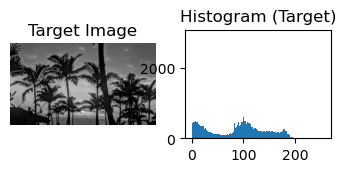

In [40]:
plt.subplot(3, 3, 4)
plt.imshow(image_target, cmap='gray')
plt.title('Target Image')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.hist(image_target.ravel(), 256, [0,256])
plt.title('Histogram (Target)')

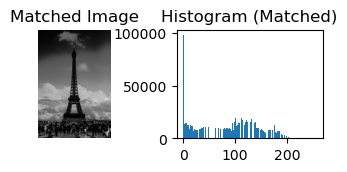

In [41]:
plt.subplot(3, 3, 7)
plt.imshow(matched_image, cmap='gray')
plt.title('Matched Image')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.hist(matched_image.ravel(), 256, [0,256])
plt.title('Histogram (Matched)')
plt.show()

Histogram matching transforms the source image so that its intensity distribution resembles the target image. As a result, the brightness and contrast of the source image become visually similar to the target image. 

Part 4: Combining Histogram Equalization and Matching

Text(0.5, 1.0, 'Original')

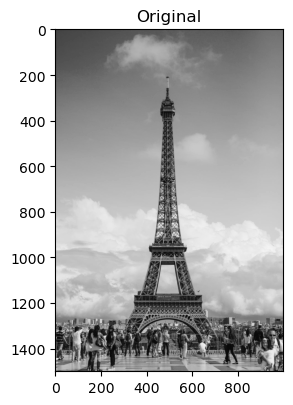

In [48]:
equalized_source = cv2.equalizeHist(image_source)

final_image = exposure.match_histograms(equalized_source, image_target)

plt.figure(figsize=(10,5))

plt.subplot(1, 3, 1)
plt.imshow(image_source, cmap='gray')
plt.title("Original")

Text(0.5, 1.0, 'Equalized')

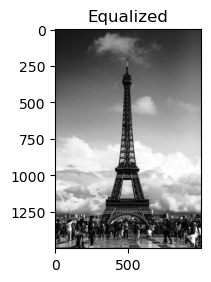

In [49]:
plt.subplot(1, 3, 2)
plt.imshow(equalized_source, cmap='gray')
plt.title("Equalized")

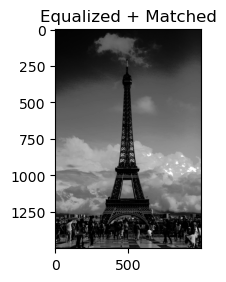

In [51]:
plt.subplot(1, 3, 3)
plt.imshow(final_image, cmap='gray')
plt.title("Equalized + Matched")

plt.show()

First, histogram equalization enhances contrast by spreading intensity values. Then, histogram matching adjusts the enhanced image to follow the brightness distribution of the target image. This combination improves detail visibility while maintaining desired lighting characteristics.